In [ ]:
!pip install -q pyroomacoustics soundfile scipy tqdm matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.1/35.1 MB 40.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
import numpy as np
import pandas as pd
import pyroomacoustics as pra
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import itertools
import warnings
import os

warnings.filterwarnings('ignore')
np.random.seed(42)

print("Libraries loaded.")

Libraries loaded.


## 1. Material Library
Absorption coefficients (α) are single-number values averaged across 250–2000 Hz,  
drawn from standard acoustic reference tables (ISO 354 / Kuttruff 2017).

In [ ]:
# ── Absorption coefficients (α) ──────────────────────────────────────────
# Source: Kuttruff (2017) Room Acoustics, Table A.1; Everest & Pohlmann (2015)
# Values are single-number averages (250 Hz – 2 kHz octave bands)
ABSORPTION = {
    # Wall materials (match CLIP detector labels)
    "painted_plaster" : 0.07,   # common domestic wall
    "concrete"         : 0.03,   # hard, very reflective
    "wood_panel"       : 0.15,   # medium absorption
    "brick"            : 0.03,   # hard masonry
    "glass"            : 0.04,   # window / glazed surface

    # Floor materials
    "carpet"           : 0.45,   # thick pile carpet
    "wood_floor"       : 0.20,   # hardwood / laminate
    "tile"             : 0.01,   # ceramic / porcelain
    "concrete_floor"   : 0.03,   # bare concrete floor

    # Ceiling materials
    "gypsum"           : 0.10,   # plasterboard / drywall
    "wood_panel_ceil"  : 0.15,   # wooden ceiling panels

    # Treatment
    "acoustic_panel"   : 0.90,   # high-performance foam/fabric panel
}

# ── Material choice sets ──────────────────────────────────────────────────
WALL_CHOICES  = ["painted_plaster", "concrete", "wood_panel", "brick", "glass"]
FLOOR_CHOICES = ["carpet", "wood_floor", "tile", "concrete_floor"]
CEIL_CHOICES  = ["painted_plaster", "gypsum", "wood_panel_ceil", "tile"]

PANEL_ALPHA = ABSORPTION["acoustic_panel"]

all_combos = list(itertools.product(WALL_CHOICES, FLOOR_CHOICES, CEIL_CHOICES))
print(f"Total material combinations: {len(all_combos)}")
print(f"  Wall options  : {len(WALL_CHOICES)}")
print(f"  Floor options : {len(FLOOR_CHOICES)}")
print(f"  Ceiling options: {len(CEIL_CHOICES)}")

Total material combinations: 80
  Wall options  : 5
  Floor options : 4
  Ceiling options: 4


## 2. Absorption Coefficient Reference Table

In [ ]:
# Display absorption coefficient table for thesis documentation
df_abs = pd.DataFrame([
    {"Material": k, "α (avg)": v, "Acoustic character": (
        "Very absorptive" if v >= 0.40 else
        "Moderately absorptive" if v >= 0.12 else
        "Mildly absorptive" if v >= 0.06 else
        "Highly reflective"
    )}
    for k, v in ABSORPTION.items() if k != "acoustic_panel"
]).sort_values("α (avg)", ascending=False).reset_index(drop=True)

display(df_abs)

,Material,α (avg),Acoustic character
0,carpet,0.45,Very absorptive
1,wood_floor,0.20,Moderately absorptive
2,wood_panel,0.15,Moderately absorptive
3,wood_panel_ceil,0.15,Moderately absorptive
4,gypsum,0.10,Mildly absorptive
5,painted_plaster,0.07,Mildly absorptive
6,glass,0.04,Highly reflective
7,concrete,0.03,Highly reflective
8,brick,0.03,Highly reflective
9,concrete_floor,0.03,Highly reflective


## 3. Simulation Helpers

In [ ]:
def effective_absorption(L, W, H, wall_a, floor_a, ceil_a):
    # Compute area-weighted mean absorption coefficient (Sabine model input).
    # Surface areas: 4 walls + floor + ceiling.

    wall_area  = 2 * (L * H + W * H)
    floor_area = L * W
    ceil_area  = L * W
    total_area = wall_area + floor_area + ceil_area
    total_abs  = wall_a * wall_area + floor_a * floor_area + ceil_a * ceil_area
    return total_abs / total_area


def sabine_rt60(V, S_alpha):
    # Sabine formula: RT60 = 0.161 * V / (S * alpha_mean)
    return 0.161 * V / (S_alpha + 1e-9)


def rt60_from_edc(rir, fs, db_start=-5.0, db_end=-35.0):

    # Estimate RT60 from a room impulse response using the Schroeder
    # backward integration method (T30 extrapolated to 60 dB).
    # Returns None if the decay region is too short to fit reliably.

    rir = np.asarray(rir, dtype=float)
    rir = rir / (np.max(np.abs(rir)) + 1e-12)

    edc = np.cumsum(rir[::-1] ** 2)[::-1]
    edc /= np.max(edc) + 1e-12
    edc_db = 10.0 * np.log10(edc + 1e-12)

    idx_start = np.where(edc_db <= db_start)[0]
    idx_end   = np.where(edc_db <= db_end)[0]

    if len(idx_start) == 0 or len(idx_end) == 0:
        return None

    i1, i2 = idx_start[0], idx_end[0]
    if i2 <= i1 + 20:
        return None

    t = np.arange(i1, i2) / fs
    y = edc_db[i1:i2]
    slope, _ = np.polyfit(t, y, 1)

    if slope >= 0:
        return None

    rt60 = -60.0 / slope
    return float(np.clip(rt60, 0.05, 15.0))


def simulate_room(L, W, H, wall_a, floor_a, ceil_a,
                  panel_coverage, fs=16_000, max_order=25):

    margin = min(0.7, L * 0.15, W * 0.15)

    def rand_pos():
        return [
            np.random.uniform(margin, L - margin),
            np.random.uniform(margin, W - margin),
            np.random.uniform(1.2, max(1.25, H - 0.5)),
        ]

    src = rand_pos()
    mic = rand_pos()
    while np.linalg.norm(np.array(src) - np.array(mic)) < 0.5:
        mic = rand_pos()   # enforce minimum source-mic separation

    def build_and_measure(w_a):
        alpha_eff = effective_absorption(L, W, H, w_a, floor_a, ceil_a)
        alpha_eff = float(np.clip(alpha_eff, 0.01, 0.95))
        room = pra.ShoeBox(
            [L, W, H],
            fs=fs,
            materials=pra.Material(alpha_eff),
            max_order=max_order,
            air_absorption=True,
        )
        room.add_source(src)
        room.add_microphone_array(pra.MicrophoneArray(np.array([mic]).T, fs))
        room.compute_rir()
        return rt60_from_edc(room.rir[0][0], fs)

    rt60_b = build_and_measure(wall_a)

    treated_wall_a = float(np.clip(
        wall_a + panel_coverage * (PANEL_ALPHA - wall_a),
        wall_a, 0.95
    ))
    rt60_a = build_and_measure(treated_wall_a)

    if rt60_b is None or rt60_a is None:
        return None, None, None, None

    return rt60_b, rt60_a, src, mic


print("Helper functions defined.")
print("simulate_room() now returns (rt60_before, rt60_after, src, mic).")


Helper functions defined.
simulate_room() now returns (rt60_before, rt60_after, src, mic).


### Smoke test — single room simulation

In [ ]:
# Quick sanity check before running the full generation
rt_b, rt_a, src_sm, mic_sm = simulate_room(
    L=4.5, W=3.8, H=2.7,
    wall_a=ABSORPTION["painted_plaster"],
    floor_a=ABSORPTION["carpet"],
    ceil_a=ABSORPTION["gypsum"],
    panel_coverage=0.40,
)
print(f"Smoke test — RT60 before: {rt_b:.3f}s  |  after: {rt_a:.3f}s  |  delta: {rt_b-rt_a:.3f}s")
print(f"  Source position : x={src_sm[0]:.2f}  y={src_sm[1]:.2f}  z={src_sm[2]:.2f}")
print(f"  Mic    position : x={mic_sm[0]:.2f}  y={mic_sm[1]:.2f}  z={mic_sm[2]:.2f}")
assert rt_b is not None and rt_a is not None, "Simulation failed"
assert rt_b > rt_a, f"Expected improvement but got before={rt_b:.3f}, after={rt_a:.3f}"
print("✓ Smoke test passed.")


Smoke test — RT60 before: 0.393s  |  after: 0.248s  |  delta: 0.145s
  Source position : x=1.83  y=3.10  z=1.93
  Mic    position : x=2.58  y=0.99  z=1.36
✓ Smoke test passed.


## 4. Stratified Dataset Generation
Each of the 80 material combinations receives exactly `SAMPLES_PER_COMBO` rows.  
Panel coverage is sampled uniformly from **0.0 → 0.75**.

Source and microphone positions are saved as `src_x/y/z` and `mic_x/y/z`.  
These represent the actual simulation positions used to compute each RT60 value,  
making them first-class features rather than hidden noise in the target variable.


In [ ]:
SAMPLES_PER_COMBO = 200     # 80 combos × 200 = 16,000 rows
FS               = 16_000
MAX_ORDER        = 25

L_RANGE = (3.0, 6.5)
W_RANGE = (3.0, 5.5)
H_RANGE = (2.4, 3.2)

rows = []
skipped = 0

for wall_mat, floor_mat, ceil_mat in tqdm(all_combos, desc="Material combos"):
    wall_a  = ABSORPTION[wall_mat]
    floor_a = ABSORPTION[floor_mat]
    ceil_a  = ABSORPTION[ceil_mat]

    attempts  = 0
    collected = 0

    while collected < SAMPLES_PER_COMBO:
        attempts += 1
        if attempts > SAMPLES_PER_COMBO * 5:
            print(f"  WARNING: combo ({wall_mat}/{floor_mat}/{ceil_mat}) only got {collected} samples")
            break

        L = np.random.uniform(*L_RANGE)
        W = np.random.uniform(*W_RANGE)
        H = np.random.uniform(*H_RANGE)
        panel_coverage = np.random.uniform(0.0, 0.75)

        # simulate_room now returns src and mic alongside RT60 values
        rt60_b, rt60_a, src, mic = simulate_room(
            L, W, H, wall_a, floor_a, ceil_a,
            panel_coverage, fs=FS, max_order=MAX_ORDER
        )

        if rt60_b is None:   # None, None, None, None on failure
            skipped += 1
            continue

        V = L * W * H
        alpha_eff_before = effective_absorption(L, W, H, wall_a, floor_a, ceil_a)
        sabine_before = sabine_rt60(V, alpha_eff_before * (2*(L*H+W*H) + 2*L*W))

        treated_wall_a = float(np.clip(
            wall_a + panel_coverage * (PANEL_ALPHA - wall_a), wall_a, 0.95))
        alpha_eff_after = effective_absorption(L, W, H, treated_wall_a, floor_a, ceil_a)
        sabine_after = sabine_rt60(V, alpha_eff_after * (2*(L*H+W*H) + 2*L*W))

        rows.append({
            # ── Geometry ─────────────────────────────────────────────────
            "L": round(L, 4),
            "W": round(W, 4),
            "H": round(H, 4),
            "volume_m3": round(V, 4),
            # ── Source & microphone positions (metres) ────────────────────
            "src_x": round(src[0], 4),
            "src_y": round(src[1], 4),
            "src_z": round(src[2], 4),
            "mic_x": round(mic[0], 4),
            "mic_y": round(mic[1], 4),
            "mic_z": round(mic[2], 4),
            # ── Materials ────────────────────────────────────────────────
            "wall_mat"  : wall_mat,
            "floor_mat" : floor_mat,
            "ceil_mat"  : ceil_mat,
            "wall_a"    : wall_a,
            "floor_a"   : floor_a,
            "ceil_a"    : ceil_a,
            # ── Treatment ────────────────────────────────────────────────
            "panel_coverage" : round(panel_coverage, 4),
            "treated_wall_a" : round(treated_wall_a, 4),
            # ── Physics cross-check ───────────────────────────────────────
            "alpha_eff_before"  : round(alpha_eff_before, 6),
            "alpha_eff_after"   : round(alpha_eff_after, 6),
            "sabine_rt60_before": round(sabine_before, 4),
            "sabine_rt60_after" : round(sabine_after, 4),
            # ── ISM simulation targets ────────────────────────────────────
            "rt60_before" : round(rt60_b, 4),
            "rt60_after"  : round(rt60_a, 4),
            "rt60_delta"  : round(rt60_b - rt60_a, 4),
        })
        collected += 1

df = pd.DataFrame(rows)
print(f"\nGeneration complete.")
print(f"  Total rows    : {len(df):,}")
print(f"  Skipped       : {skipped:,}")
print(f"  Combos present: {df.groupby(['wall_mat','floor_mat','ceil_mat']).ngroups}")
print(f"  Columns       : {list(df.columns)}")


Material combos: 100%|██████████| 80/80 [28:45<00:00, 21.57s/it]


Generation complete.
  Total rows    : 16,000
  Skipped       : 0
  Combos present: 80
  Columns       : ['L', 'W', 'H', 'volume_m3', 'src_x', 'src_y', 'src_z', 'mic_x', 'mic_y', 'mic_z', 'wall_mat', 'floor_mat', 'ceil_mat', 'wall_a', 'floor_a', 'ceil_a', 'panel_coverage', 'treated_wall_a', 'alpha_eff_before', 'alpha_eff_after', 'sabine_rt60_before', 'sabine_rt60_after', 'rt60_before', 'rt60_after', 'rt60_delta']


## 5. Data Quality & Validation

In [ ]:
# ── Basic statistics ──────────────────────────────────────────────────
print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"  Shape         : {df.shape}")
print(f"  Missing values: {df.isnull().sum().sum()}")
print()

numeric_cols = ["L","W","H",
                "src_x","src_y","src_z",
                "mic_x","mic_y","mic_z",
                "wall_a","floor_a","ceil_a",
                "panel_coverage","rt60_before","rt60_after","rt60_delta"]
print(df[numeric_cols].describe().round(4).to_string())
print()

# ── Spatial position sanity checks ────────────────────────────────────
print("SPATIAL POSITION CHECKS")
print(f"  src_x inside [0, L]:  {((df.src_x > 0) & (df.src_x < df.L)).all()}")
print(f"  src_y inside [0, W]:  {((df.src_y > 0) & (df.src_y < df.W)).all()}")
print(f"  mic_x inside [0, L]:  {((df.mic_x > 0) & (df.mic_x < df.L)).all()}")
print(f"  mic_y inside [0, W]:  {((df.mic_y > 0) & (df.mic_y < df.W)).all()}")
sep = np.sqrt((df.src_x-df.mic_x)**2 + (df.src_y-df.mic_y)**2 + (df.src_z-df.mic_z)**2)
print(f"  Min src-mic separation: {sep.min():.3f} m  (should be > 0.5 m)")
print()

# ── RT60 sanity checks ────────────────────────────────────────────────
n_improved = (df["rt60_delta"] > 0).sum()
pct_improved = n_improved / len(df) * 100
print(f"RT60 improvement rate : {pct_improved:.1f}%  ({n_improved:,} / {len(df):,})")
print(f"RT60 before range     : {df['rt60_before'].min():.3f}s — {df['rt60_before'].max():.3f}s")
print(f"RT60 after  range     : {df['rt60_after'].min():.3f}s  — {df['rt60_after'].max():.3f}s")

extreme = df[(df["rt60_before"] > 10) | (df["rt60_after"] > 10)]
print(f"\nRows with RT60 > 10s (potential outliers): {len(extreme)}")
if len(extreme):
    display(extreme[["L","W","H","wall_mat","floor_mat","rt60_before","rt60_after"]].head())


DATASET OVERVIEW
  Shape         : (16000, 25)
  Missing values: 0

                L           W           H       src_x       src_y       src_z       mic_x       mic_y       mic_z      wall_a     floor_a      ceil_a  panel_coverage  rt60_before  rt60_after  rt60_delta
count  16000.0000  16000.0000  16000.0000  16000.0000  16000.0000  16000.0000  16000.0000  16000.0000  16000.0000  16000.0000  16000.0000  16000.0000      16000.0000   16000.0000  16000.0000  16000.0000
mean       4.7498      4.2549      2.8017      2.3782      2.1345      1.7518      2.3789      2.1179      1.7474      0.0640      0.1725      0.0825          0.3745       0.4584      0.3425      0.1159
std        1.0138      0.7212      0.2307      1.1866      0.9859      0.3448      1.1807      0.9726      0.3455      0.0454      0.1764      0.0507          0.2159       0.0816      0.1069      0.0970
min        3.0001      3.0000      2.4001      0.4646      0.4590      1.2000      0.4526      0.4592      1.2000      0

## 6. Exploratory Data Analysis

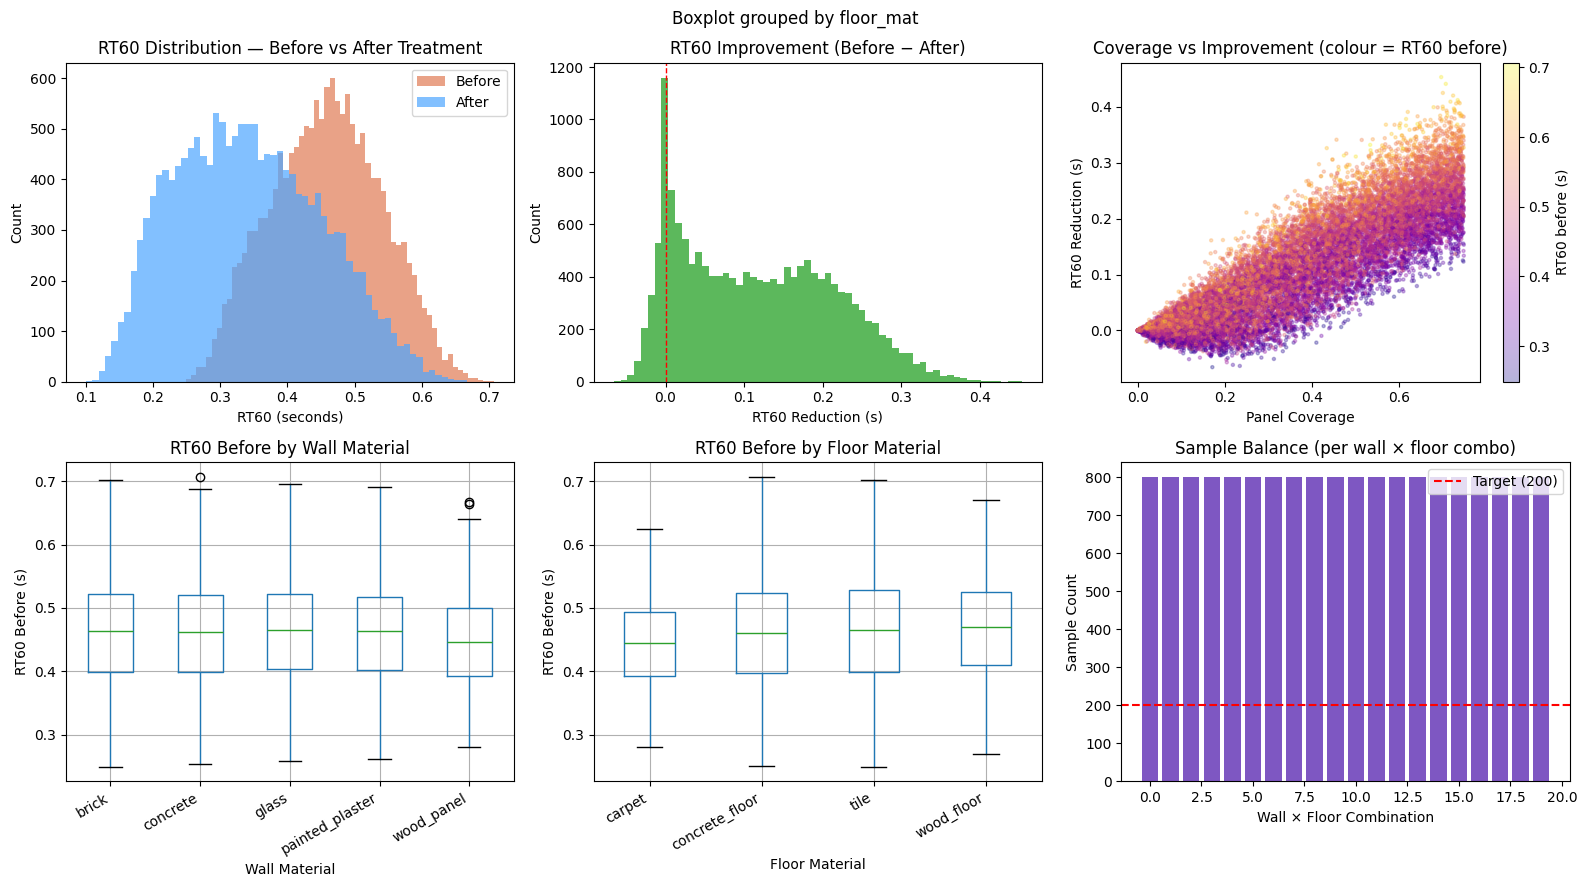

EDA plots saved to eda_plots.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("AcuVisor Dataset — Exploratory Data Analysis", fontsize=14, fontweight='bold')

# ── RT60 distribution ────────────────────────────────────────────────
ax = axes[0, 0]
ax.hist(df["rt60_before"], bins=60, alpha=0.7, color="#E07B54", label="Before")
ax.hist(df["rt60_after"],  bins=60, alpha=0.7, color="#4DA6FF", label="After")
ax.set_xlabel("RT60 (seconds)")
ax.set_ylabel("Count")
ax.set_title("RT60 Distribution — Before vs After Treatment")
ax.legend()

# ──  RT60 delta ────────────────────────────────────────────────────────
ax = axes[0, 1]
ax.hist(df["rt60_delta"], bins=60, color="#5CB85C")
ax.axvline(0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel("RT60 Reduction (s)")
ax.set_title("RT60 Improvement (Before − After)")
ax.set_ylabel("Count")

# ── Panel coverage vs RT60 delta ─────────────────────────────────────
ax = axes[0, 2]
sc = ax.scatter(df["panel_coverage"], df["rt60_delta"],
                c=df["rt60_before"], cmap="plasma", alpha=0.3, s=5)
plt.colorbar(sc, ax=ax, label="RT60 before (s)")
ax.set_xlabel("Panel Coverage")
ax.set_ylabel("RT60 Reduction (s)")
ax.set_title("Coverage vs Improvement (colour = RT60 before)")

# ── RT60 by wall material ────────────────────────────────────────────
ax = axes[1, 0]
df.boxplot(column="rt60_before", by="wall_mat", ax=ax)
ax.set_xlabel("Wall Material")
ax.set_ylabel("RT60 Before (s)")
ax.set_title("RT60 Before by Wall Material")
plt.sca(ax); plt.xticks(rotation=30, ha='right')

# ── RT60 by floor material ───────────────────────────────────────────
ax = axes[1, 1]
df.boxplot(column="rt60_before", by="floor_mat", ax=ax)
ax.set_xlabel("Floor Material")
ax.set_ylabel("RT60 Before (s)")
ax.set_title("RT60 Before by Floor Material")
plt.sca(ax); plt.xticks(rotation=30, ha='right')

# ──  Samples per material combo (balance check) ──────────────────────
ax = axes[1, 2]
combo_counts = df.groupby(["wall_mat","floor_mat"]).size().reset_index(name='n')
ax.bar(range(len(combo_counts)), combo_counts['n'], color='#7E57C2')
ax.axhline(SAMPLES_PER_COMBO, color='red', linestyle='--', label=f'Target ({SAMPLES_PER_COMBO})')
ax.set_xlabel("Wall × Floor Combination")
ax.set_ylabel("Sample Count")
ax.set_title("Sample Balance (per wall × floor combo)")
ax.legend()

plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150, bbox_inches='tight')
plt.show()
print("EDA plots saved to eda_plots.png")

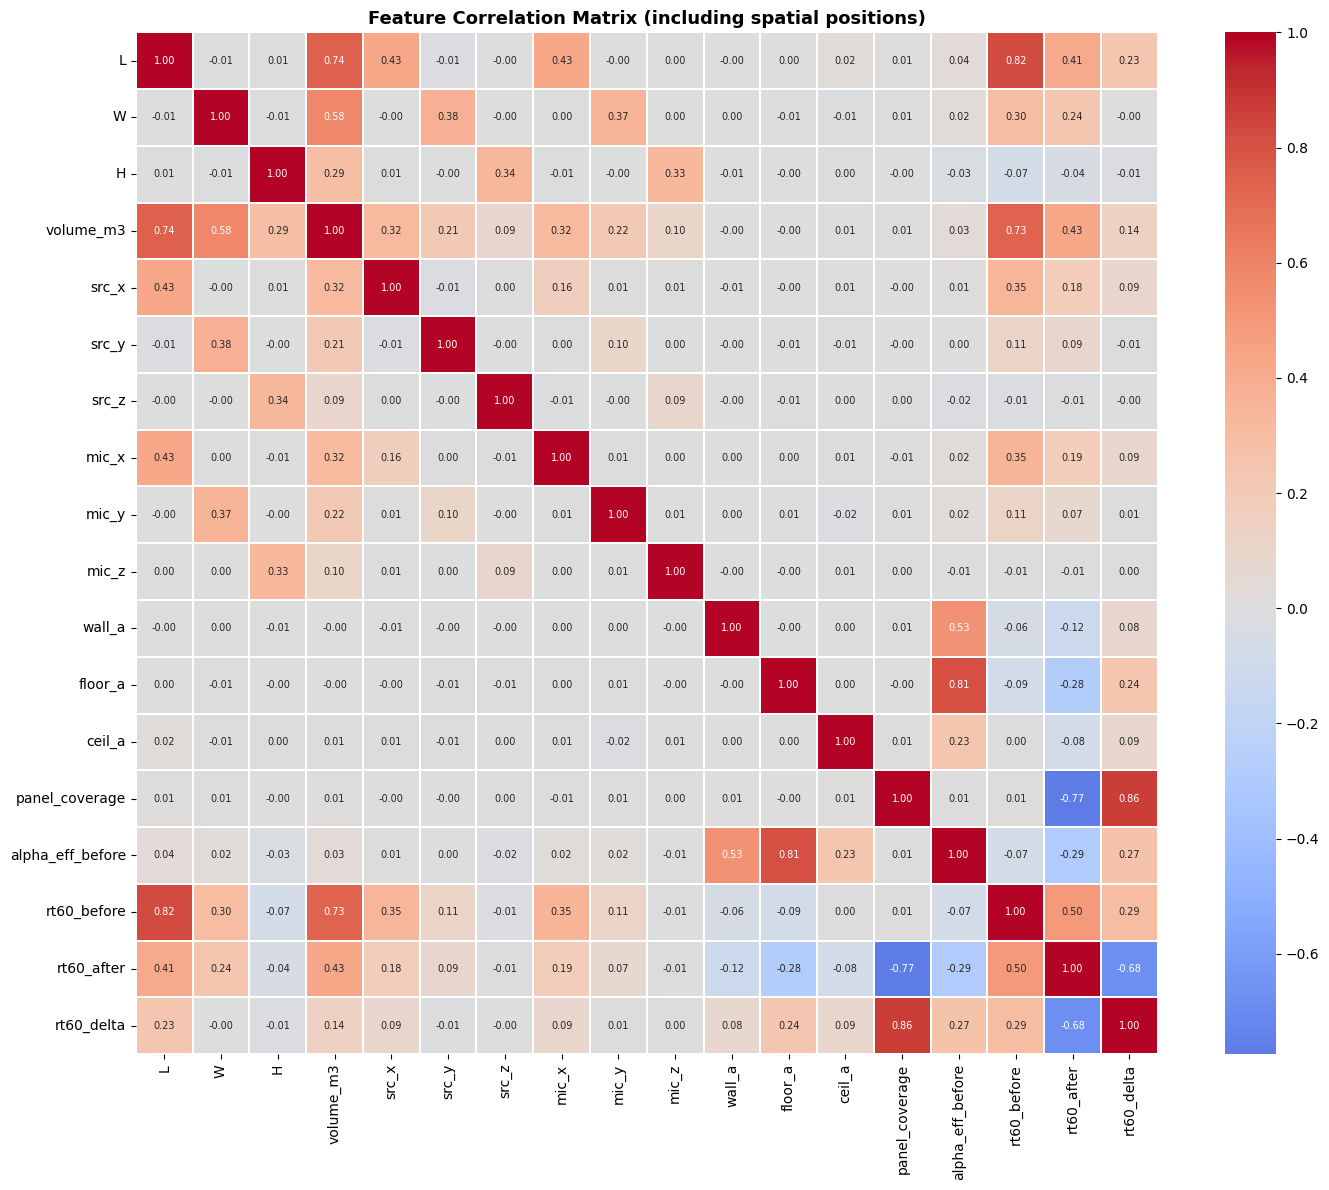

Correlation of spatial features with rt60_after:
mic_x    0.1857
src_x    0.1830
src_y    0.0896
mic_y    0.0737
mic_z   -0.0104
src_z   -0.0087

Note: low raw correlation is expected — spatial effects are nonlinear.
The MLP will capture interaction effects that Pearson correlation cannot.


In [ ]:
# Correlation heatmap including spatial position features
corr_cols = ["L","W","H","volume_m3",
             "src_x","src_y","src_z",
             "mic_x","mic_y","mic_z",
             "wall_a","floor_a","ceil_a",
             "panel_coverage","alpha_eff_before",
             "rt60_before","rt60_after","rt60_delta"]

corr = df[corr_cols].corr()

plt.figure(figsize=(15, 12))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.3, square=True, annot_kws={"size": 7})
plt.title("Feature Correlation Matrix (including spatial positions)",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Correlation of spatial features with RT60 specifically ────────────────
print("Correlation of spatial features with rt60_after:")
spatial_corr = corr.loc[["src_x","src_y","src_z","mic_x","mic_y","mic_z"],
                         "rt60_after"].sort_values(key=abs, ascending=False)
print(spatial_corr.round(4).to_string())
print()
print("Note: low raw correlation is expected — spatial effects are nonlinear.")
print("The MLP will capture interaction effects that Pearson correlation cannot.")


### Per-combo RT60 summary (thesis table)

In [ ]:
combo_summary = df.groupby(["wall_mat","floor_mat","ceil_mat"]).agg(
    n=("rt60_before","count"),
    rt60_before_mean=("rt60_before","mean"),
    rt60_before_std=("rt60_before","std"),
    rt60_after_mean=("rt60_after","mean"),
    rt60_delta_mean=("rt60_delta","mean"),
    pct_improved=("rt60_delta", lambda x: (x>0).mean()*100)
).round(3).reset_index()

combo_summary.columns = ["Wall","Floor","Ceiling","N",
                          "RT60_before_mean","RT60_before_std",
                          "RT60_after_mean","ΔRT60_mean","% improved"]
display(combo_summary)

,Wall,Floor,Ceiling,N,RT60_before_mean,RT60_before_std,RT60_after_mean,ΔRT60_mean,% improved
0,brick,carpet,gypsum,200,0.454,0.069,0.304,0.150,99.0
1,brick,carpet,painted_plaster,200,0.453,0.072,0.316,0.137,98.5
2,brick,carpet,tile,200,0.464,0.077,0.313,0.151,98.0
3,brick,carpet,wood_panel_ceil,200,0.451,0.065,0.291,0.159,99.5
4,brick,concrete_floor,gypsum,200,0.451,0.089,0.371,0.080,76.5
...,...,...,...,...,...,...,...,...,...
75,wood_panel,tile,wood_panel_ceil,200,0.469,0.068,0.341,0.128,100.0
76,wood_panel,wood_floor,gypsum,200,0.453,0.064,0.311,0.142,99.5
77,wood_panel,wood_floor,painted_plaster,200,0.452,0.069,0.308,0.144,100.0
78,wood_panel,wood_floor,tile,200,0.453,0.072,0.327,0.126,99.0


## 7. Save Dataset

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

SAVE_DIR = "/content/drive/MyDrive/AcuVisor"
os.makedirs(SAVE_DIR, exist_ok=True)

csv_path = os.path.join(SAVE_DIR, "synthetic_acoustics_dataset_v3.csv")
df.to_csv(csv_path, index=False)
df.to_csv("synthetic_acoustics_dataset_v3.csv", index=False)  # local copy

print(f"Dataset saved: {csv_path}")
print(f"Shape        : {df.shape}")
print(f"File size    : {os.path.getsize(csv_path)/1024:.1f} KB")
print()
print("New columns vs v2:")
new_cols = ["src_x","src_y","src_z","mic_x","mic_y","mic_z"]
print(f"  {new_cols}")
print()
